# 注意力汇聚：Nadaraya-Watson回归

注意力怎么做加权平均？

## 生成数据集

生成带噪声的人工数据集：
$$y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon \tag{10.2.1}$$

* $x_i$ 为输入的样本特征；
* $\epsilon$ 是加入的噪声项，服从均值为 $0$、标准差为 $0.5$ 的正态分布（即 $\epsilon \sim \mathcal{N}(0, 0.5^2)$）。

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
# 绘制训练样本（原点）， 不带噪声的真实数据生成函数f，学习得到的预测函数pred
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);


c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 平均汇聚
$$f(x) = \frac{1}{n} \sum_{i=1}^n y_i \tag{10.2.2}$$

平均汇聚忽略了输入$x_i$

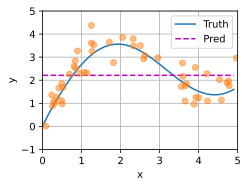

In [ ]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)  # 把y_train.mean()重复n_test次
plot_kernel_reg(y_hat)

## 非参数注意力汇聚

根据数据点平滑的预测结果：
$$f(x) = \sum_{i=1}^n \frac{K(x - x_i)}{\sum_{j=1}^n K(x - x_j)} y_i$$
其中K是核函数

前面的一个项本质上是算分配权重的，可以重写成公式：
$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i $$


* $x$（待预测的测试输入） $\Longleftrightarrow$ 查询（Query）：  

* $x_i$（已有训练样本的输入） $\Longleftrightarrow$ 键（Key）：

key 是用来和 Query 进行匹配、寻址的特征标识。模型需要衡量待预测的 $x$ 和历史数据库中的哪个输入 $x_i$ 最像、距离最近。

* $y_i$（已有训练样本的输出） $\Longleftrightarrow$ 值（Value）：

Value 是最终要被提取和聚合的实际内容。在这里，每个历史键 $x_i$ 背后绑定的真实标签/输出就是 $y_i$。

* $\alpha(x, x_i)$ $\Longleftrightarrow$ 注意力权重（Attention Weight）

它衡量了 Query（$x$）与各个 Key（$x_i$）之间的相关程度/相似度，决定了最终输出应该分多少“注意力”给该 Key 对应的 Value（$y_i$）。

对于每个测试输入的x，模型会看他和$x_i$的相关程度，根据相关程度去给注意力权重

下面考虑一个高斯核：
$$K(u) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{u^2}{2}\right)$$

把高斯核代入上面的公式可以推导出：
$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i = \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}(x - x_j)^2\right)} y_i = \sum_{i=1}^n \text{softmax}\left(-\frac{1}{2}(x - x_i)^2\right) y_i $$

也就是说：一个key($x_i$)越是接近Query($x$)，那么他分到的注意力权重就越大。

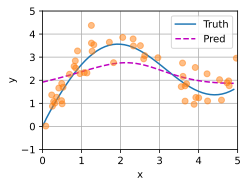

In [3]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

观察注意力权重$attention_weights$
测试数据的输入相当于Query， 训练数据的输入相当于key， 因为两个输入都是经过排序的，因此由观察可知“查询-键”对越接近， 注意力汇聚的注意力权重就越高

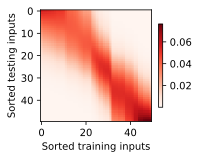

In [4]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

## 带参数注意力汇聚

在query和key之间引入可以学习的参数$\omega$:

$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i = \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)} y_i = \sum_{i=1}^n \text{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i \tag{10.2.7}$$

### 批量矩阵乘法

假设有两个三维张量 $\mathbf{X}$ 和 $\mathbf{Y}$：
* $\mathbf{X} \in \mathbb{R}^{n \times a \times b}$（包含 $n$ 个大小为 $a \times b$ 的矩阵）
* $\mathbf{Y} \in \mathbb{R}^{n \times b \times c}$（包含 $n$ 个大小为 $b \times c$ 的矩阵）

批量矩阵乘法（Batch Matrix Multiplication）要求这两个张量的第 0 维（即 Batch 维度 $n$）必须完全相同，它对批次中的每一个样本分别做标准的二维矩阵乘法：$$\mathbf{Z}_i = \mathbf{X}_i \mathbf{Y}_i \quad (i = 1, 2, \dots, n)$$

维度上：

$$(n, \mathbf{a}, \underline{\mathbf{b}}) \times (n, \underline{\mathbf{b}}, \mathbf{c}) \longrightarrow (n, \mathbf{a}, \mathbf{c})$$

In [5]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

在注意力机制的背景下，可以用小批量矩阵乘法来计算小批量数据中的加权平均值

In [6]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

### 定义模型

使用小批量矩阵乘法

In [9]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))  # 每一个query都要和一整排的key做比较
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)  # 用注意力权重，对每个value去做加权平均

### 训练

训练时，每一个训练样本都拿自己当 Query，然后拿“其他训练样本”当 Key-Value，去预测自己的 y，所以需要去掉对角线上的元素

In [7]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))  # eye生成单位矩阵，这里是为了去掉对角线上的元素
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

在训练的时候，使用平法损失和随机梯度下降

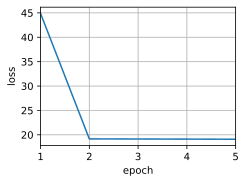

In [10]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

### 预测

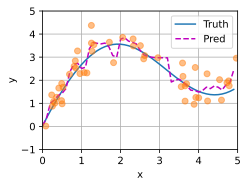

In [11]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

这里预测得到的新的模型反而不再平滑了

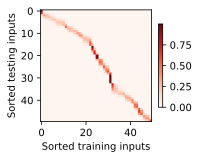

In [12]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

不平滑的原因是，注意力越尖锐，预测结果越依赖于当前样本，而不是基于所有样本的平均值